In [1]:
import chess 
import chess.syzygy
import chess.svg
import networkx as nx

ModuleNotFoundError: No module named 'chess.syzygy'; 'chess' is not a package

In [2]:
import os
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

# Configuration
BASE_URL = "http://tablebase.sesse.net/syzygy/3-4-5/"
SAVE_FOLDER = "syzygy_345"

# This header tells the server you are a browser, not a bot
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

def download_syzygy_files(url, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    print(f"Connecting to {url}...")
    try:
        # Pass the HEADERS here
        response = requests.get(url, headers=HEADERS)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Failed to connect: {e}")
        return

    soup = BeautifulSoup(response.text, 'html.parser')
    links = [urljoin(url, a['href']) for a in soup.find_all('a', href=True) 
             if a['href'].endswith(('.rtbw', '.rtbz'))]

    print(f"Found {len(links)} files. starting download...")

    for i, file_url in enumerate(links, 1):
        filename = os.path.basename(file_url)
        file_path = os.path.join(output_dir, filename)

        if os.path.exists(file_path):
            print(f"[{i}/{len(links)}] Skipping {filename}")
            continue

        try:
            # Pass HEADERS here too for the actual file download
            with requests.get(file_url, headers=HEADERS, stream=True, timeout=30) as r:
                r.raise_for_status()
                with open(file_path, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=16384):
                        f.write(chunk)
            print(f"[{i}/{len(links)}] Finished: {filename}")
        except Exception as e:
            print(f"[{i}/{len(links)}] Error downloading {filename}: {e}")

download_syzygy_files(BASE_URL, SAVE_FOLDER)

Connecting to http://tablebase.sesse.net/syzygy/3-4-5/...
Found 290 files. starting download...
[1/290] Skipping KBBBvK.rtbw
[2/290] Skipping KBBBvK.rtbz
[3/290] Skipping KBBNvK.rtbw
[4/290] Skipping KBBNvK.rtbz
[5/290] Skipping KBBPvK.rtbw
[6/290] Skipping KBBPvK.rtbz
[7/290] Skipping KBBvK.rtbw
[8/290] Skipping KBBvK.rtbz
[9/290] Skipping KBBvKB.rtbw
[10/290] Skipping KBBvKB.rtbz
[11/290] Skipping KBBvKN.rtbw
[12/290] Skipping KBBvKN.rtbz
[13/290] Skipping KBBvKP.rtbw
[14/290] Skipping KBBvKP.rtbz
[15/290] Skipping KBBvKQ.rtbw
[16/290] Skipping KBBvKQ.rtbz
[17/290] Skipping KBBvKR.rtbw
[18/290] Skipping KBBvKR.rtbz
[19/290] Skipping KBNNvK.rtbw
[20/290] Skipping KBNNvK.rtbz
[21/290] Skipping KBNPvK.rtbw
[22/290] Skipping KBNPvK.rtbz
[23/290] Skipping KBNvK.rtbw
[24/290] Skipping KBNvK.rtbz
[25/290] Skipping KBNvKB.rtbw
[26/290] Skipping KBNvKB.rtbz
[27/290] Skipping KBNvKN.rtbw
[28/290] Skipping KBNvKN.rtbz
[29/290] Skipping KBNvKP.rtbw
[30/290] Skipping KBNvKP.rtbz
[31/290] Skipping

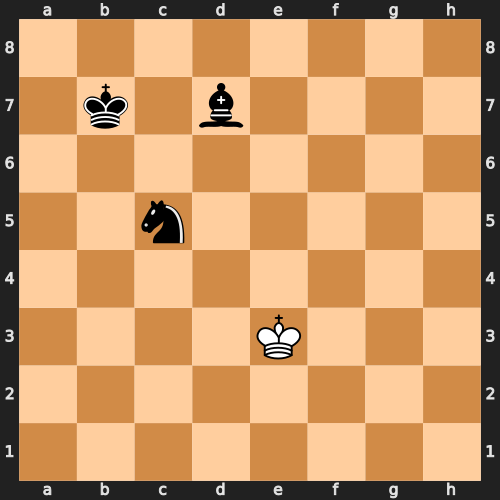

In [3]:
board = chess.Board("8/1k1b4/8/2n5/8/4K3/8/8 w - - 0 1")

def plot(board, arrows=[]):
    return chess.svg.board(board, arrows=arrows, size=500)  

plot(board)

In [4]:
tablebase = chess.syzygy.open_tablebase(".\syzygy_345")

In [5]:
def plot_legal_moves(board):
    arrows = []
    for move in board.legal_moves:
        arrows.append(chess.svg.Arrow(move.from_square, move.to_square, color="#0000cccc"))
    return plot(board, arrows=arrows)

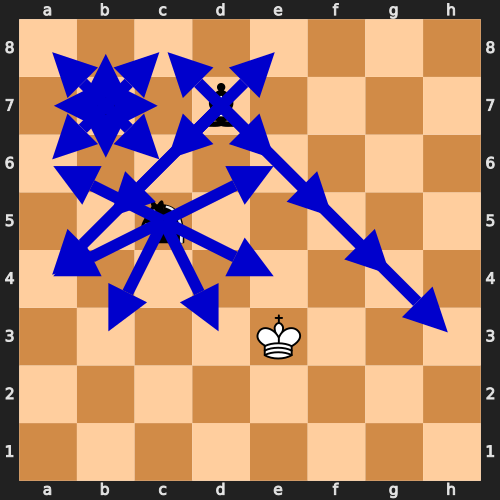

In [6]:
board = chess.Board("8/1k1b4/8/2n5/8/4K3/8/8 b - - 0 1")
plot_legal_moves(board)

In [7]:
from IPython.display import display, clear_output
import time
import os

In [20]:
def get_node_name(board, starting_color):
    epd_i = board.epd()
    color = epd_i[-5]

    wdl = tablebase.probe_wdl(board)
    if color != starting_color:
        wdl = -wdl
    
    return epd_i[0 : len(epd_i) - 6] + ":" + color + ":" + str(wdl)

In [ ]:
file = open("KRvK.adj", "w")

S = set()

# original: 8/4k3/8/1R6/8/8/4K3/8 w - - 0 1
starting_fen = "1k6/3r4/1K6/3B4/8/8/8/8 w - - 0 1"
starting_color = "w"

board = chess.Board(starting_fen)

stack = [board.fen()]
S.add(board.epd())

while stack:
    print(f"{len(stack)}, {len(S)}       ", end="\r")
    fen_i = stack.pop()
    board = chess.Board(fen_i)
    epd_i = board.epd()
    i = get_node_name(board, starting_color)

    # 8/4k3/8/1R6/8/8/4K3/8:w:wdl
    
    #print(epd_i)
    #if len(S) > 100000:
    #    clear_output(wait=True)
    #    display(board)
    #time.sleep(1)
    
    if board.is_game_over():
        continue
    
    legal_moves = board.legal_moves
    for move in legal_moves:
        board.push(move)
        fen_j = board.fen()
        epd_j = board.epd()
        j = get_node_name(board, starting_color)
        if epd_j not in S:
            S.add(epd_j)
            stack.append(fen_j)
        file.write(f"{i} {j}\n")
        
        board.pop()

file.close()

1393, 113811       

In [22]:
G = nx.read_edgelist("KRvK.adj", create_using=nx.DiGraph)

In [23]:
print(f"n: {G.number_of_nodes()}")
print(f"m: {G.number_of_edges()}")

n: 302476
m: 879797


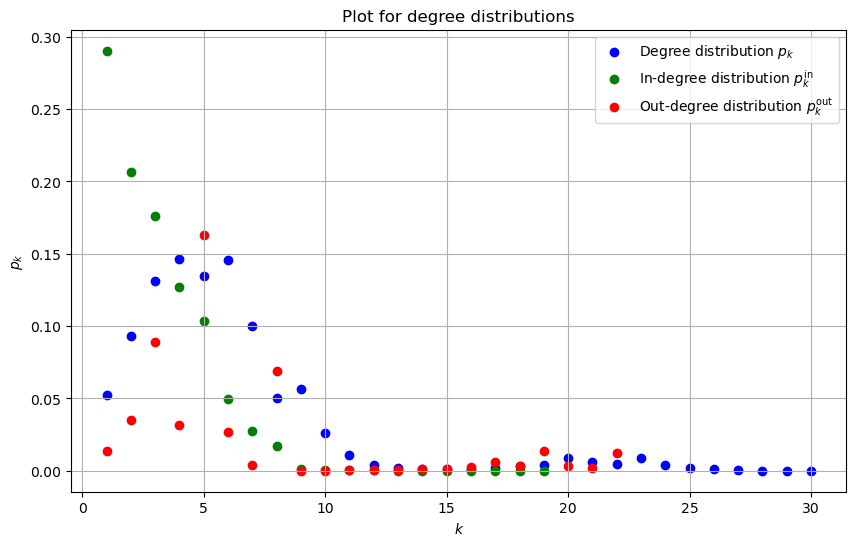

In [42]:
import matplotlib.pyplot as plt

n = G.number_of_nodes()

k_i = []
p_k = []
k_i_in = []
p_k_in = []
k_i_out = []
p_k_out = []

n_k = dict()
n_k_in = dict()
n_k_out = dict()

for u in G.nodes():
    k = G.degree(u)
    k_in = G.in_degree(u)
    k_out = G.out_degree(u)

    n_k[k] = 1 if k not in n_k else n_k[k] + 1
    n_k_in[k_in] = 1 if k_in not in n_k_in else n_k_in[k_in] + 1
    n_k_out[k_out] = 1 if k_out not in n_k_out else n_k_out[k_out] + 1

for k in n_k:
    if k > 0:
        k_i.append(k)
        p_k.append(n_k[k] / n)

for k_in in n_k_in:
    if k_in > 0:
        k_i_in.append(k_in)
        p_k_in.append(n_k_in[k_in] / n)

for k_out in n_k_out:
    if k_out > 0:
        k_i_out.append(k_out)
        p_k_out.append(n_k_out[k_out] / n)

plt.figure(figsize=(10, 6))
plt.scatter(k_i, p_k, linestyle="None", marker="o",color="blue", label="Degree distribution $p_k$")
plt.scatter(k_i_in, p_k_in, linestyle="None", marker="o", color="green", label="In-degree distribution $p_k^{\mathrm{in}}$")
plt.scatter(k_i_out, p_k_out, linestyle="None", marker="o", color="red", label="Out-degree distribution $p_k^{\mathrm{out}}$")

plt.title("Plot for degree distributions")
plt.xlabel("$k$")
plt.ylabel("$p_k$")
plt.grid(True)
plt.legend()

plt.savefig("degree_distributionX.pdf", format="pdf", bbox_inches="tight")

In [15]:
nx.write_graphml(G, "KRvK.graphml")

In [24]:
N = G.copy()
for node in N.nodes():
    wdl_value = node.split(":")[-1]
    N.nodes[node]["wdl"] = int(wdl_value)
nx.write_graphml(N, "KRvK.graphml")

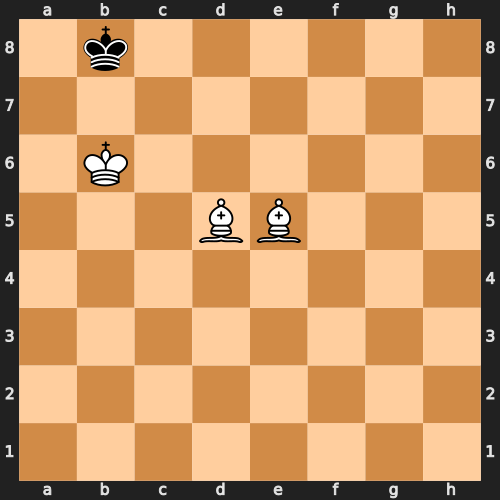

In [43]:
plot(chess.Board("1k6/8/1K6/3BB3/8/8/8/8 w - - 0 1"))